In [3]:
# ============================================================
# AI vs Human Text Detection
# Install Required Libraries
# ============================================================

!pip install -q transformers datasets accelerate
!pip install -q pandas numpy scikit-learn matplotlib seaborn tqdm

In [2]:
# ============================================================
# Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np

import torch
import torchvision
import datasets
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import transformers
from transformers import (AutoTokenizer, AutoModelForSequenceClassification)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
import random

In [4]:
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Torch:", torch.__version__)
print("TorchVision:", torchvision.__version__)

Transformers: 5.0.0
Datasets: 4.0.0
Torch: 2.11.0+cu128
TorchVision: 0.26.0+cu128


In [5]:
# ============================================================
# Set Random Seeds
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed Set Successfully")

Seed Set Successfully


In [6]:
# ==========================================
# Check GPU Availability
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

Using Device: cuda
GPU Name: Tesla T4


In [7]:
# ============================================================
# Load AI Text Detection Dataset
# ============================================================

dataset = load_dataset(
    "artem9k/ai-text-detection-pile"
)

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.87k [00:00<?, ?B/s]

data/train-00000-of-00007-bc5952582e004d(…):   0%|          | 0.00/758M [00:00<?, ?B/s]

data/train-00001-of-00007-71c80017bc45f3(…):   0%|          | 0.00/318M [00:00<?, ?B/s]

data/train-00002-of-00007-ee2d43f396e78f(…):   0%|          | 0.00/125M [00:00<?, ?B/s]

...

data/train-00004-of-00007-b269dc49374a2c(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

data/train-00005-of-00007-3dce5e05ddbad7(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

data/train-00006-of-00007-3d8a471ba0cf1c(…):   0%|          | 0.00/242M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1392522 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['source', 'id', 'text'],
        num_rows: 1392522
    })
})


In [8]:
# ============================================================
# Convert Dataset to Pandas DataFrame
# ============================================================

df = dataset["train"].to_pandas()
print("Shape:", df.shape)
df.head()

Shape: (1392522, 3)


,source,id,text
0,human,0,12 Years a Slave: An Analysis of the Film Essa...
1,human,1,20+ Social Media Post Ideas to Radically Simpl...
2,human,2,2022 Russian Invasion of Ukraine in Global Med...
3,human,3,533 U.S. 27 (2001) Kyllo v. United States: The...
4,human,4,A Charles Schwab Corporation Case Essay\n\nCha...


In [9]:
# ============================================================
# Dataset Exploration
# ============================================================

print(df.columns)
print("\nSource Distribution:")
print(df["source"].value_counts())

Index(['source', 'id', 'text'], dtype='object')

Source Distribution:
source
human    1028146
ai        364376
Name: count, dtype: int64


In [10]:
# ============================================================
# Convert Labels to Numeric Format
# ============================================================
# human -> 0
# ai -> 1

label_map = {"human": 0, "ai": 1}
df["label"] = df["source"].map(label_map)
print(df["label"].value_counts())

label
0    1028146
1     364376
Name: count, dtype: int64


In [11]:
# ============================================================
# Create Balanced Dataset
# ============================================================

human_df = df[df["label"] == 0].sample(25000, random_state=SEED)

ai_df = df[df["label"] == 1].sample(25000, random_state=SEED)

balanced_df = pd.concat([human_df, ai_df])

balanced_df = balanced_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(balanced_df.shape)

print(balanced_df["label"].value_counts())

(50000, 4)
label
1    25000
0    25000
Name: count, dtype: int64


In [12]:
# ============================================================
# Basic Text Cleaning
# ============================================================

balanced_df = balanced_df.dropna(subset=["text"])

balanced_df["text"] = (balanced_df["text"].astype(str).str.strip())

balanced_df = balanced_df[balanced_df["text"].str.len() > 0]

balanced_df = balanced_df[balanced_df["text"].apply(
        lambda x: len(x.split()) > 20
    )]

balanced_df = balanced_df.reset_index(drop=True)

print("Final Shape:")
print(balanced_df.shape)

Final Shape:
(49251, 4)


In [13]:
# ============================================================
# Train Validation Test Split
# ============================================================

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    balanced_df["text"],
    balanced_df["label"],
    test_size=0.2,
    random_state=SEED,
    stratify=balanced_df["label"]
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_labels
)

print("Training Samples:", len(train_texts))
print("Validation Samples:", len(val_texts))
print("Test Samples:", len(test_texts))

Training Samples: 39400
Validation Samples: 4925
Test Samples: 4926


In [14]:
#-------------------------------------------
# LOAD TOKENIZER
#-------------------------------------------
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [15]:
print(type(tokenizer))
print(tokenizer.name_or_path)

<class 'transformers.models.bert.tokenization_bert.BertTokenizer'>
distilbert-base-uncased


In [16]:
# ============================================================
# Custom PyTorch Dataset
# ============================================================

MAX_LENGTH = 128
class AITextDataset(Dataset):
    def __init__(
        self,
        texts,
        labels,
        tokenizer
    ):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = self.tokenizer(text, truncation=True, padding="max_length", max_length=MAX_LENGTH, return_tensors="pt")

        return {

            "input_ids":
                encoding["input_ids"].squeeze(0),

            "attention_mask":
                encoding["attention_mask"].squeeze(0),

            "labels":
                torch.tensor(
                    self.labels[idx],
                    dtype=torch.long
                )
        }

In [17]:
# ==========================================
# Creating dataset objects
# ==========================================

train_dataset = AITextDataset(
    train_texts,
    train_labels,
    tokenizer
)

val_dataset = AITextDataset(
    val_texts,
    val_labels,
    tokenizer
)

test_dataset = AITextDataset(
    test_texts,
    test_labels,
    tokenizer
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

39400
4925
4926


In [18]:
# ==========================================
# Creating Data Loaders
# ==========================================
BATCH_SIZE = 16
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [19]:
# ============================================================
# Verify DataLoader
# ============================================================

batch = next(iter(train_loader))

print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)

torch.Size([16, 128])
torch.Size([16, 128])
torch.Size([16])


In [20]:
# ==========================================
# Load DistilBert Model
# ==========================================

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.to(device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [21]:
# ============================================================
# Optimizer
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5
)

print("Optimizer Ready")

Optimizer Ready


In [22]:
# ============================================================
# Validation Function
# ============================================================

def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

            total_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())

            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)

    accuracy = accuracy_score(all_labels, all_preds)

    precision = precision_score(all_labels, all_preds)

    recall = recall_score(all_labels, all_preds)

    f1 = f1_score(all_labels, all_preds)

    return (
        avg_loss,
        accuracy,
        precision,
        recall,
        f1
    )

In [23]:
# ==========================================
# Training Loop
# ==========================================

EPOCHS = 3

train_losses = []
val_losses = []

best_f1 = 0
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    model.train()
    total_train_loss = 0
    progress_bar = tqdm(train_loader)
    for batch in progress_bar:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss
        total_train_loss += loss.item()
        loss.backward()
        optimizer.step()
        progress_bar.set_postfix(
            {"loss": loss.item()}
        )

    avg_train_loss = (total_train_loss / len(train_loader))
    train_losses.append(avg_train_loss)

    (
        val_loss,
        val_acc,
        val_precision,
        val_recall,
        val_f1
    ) = evaluate_model(
        model,
        val_loader
    )

    val_losses.append(val_loss)

    print(f"Train Loss: {avg_train_loss:.4f}")

    print(f"Val Loss: {val_loss:.4f}")

    print(f"Val Accuracy: {val_acc:.4f}")

    print(f"Val F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "best_distilbert_ai_detector.pt")
        print("Best model saved.")


Epoch 1/3


100%|██████████| 2463/2463 [08:49<00:00,  4.65it/s, loss=0.102]


Train Loss: 0.1752
Val Loss: 0.1233
Val Accuracy: 0.9496
Val F1: 0.9500
Best model saved.

Epoch 2/3


100%|██████████| 2463/2463 [08:45<00:00,  4.69it/s, loss=0.00795]


Train Loss: 0.0631
Val Loss: 0.2035
Val Accuracy: 0.9371
Val F1: 0.9397

Epoch 3/3


100%|██████████| 2463/2463 [08:32<00:00,  4.81it/s, loss=0.00339]


Train Loss: 0.0242
Val Loss: 0.1968
Val Accuracy: 0.9494
Val F1: 0.9503
Best model saved.


In [24]:
# ==========================================
# Load Best Model
# ==========================================

model.load_state_dict(
    torch.load(
        "best_distilbert_ai_detector.pt"
    )
)
print("Best Model Loaded")

Best Model Loaded


In [40]:
torch.save(
    model.state_dict(),
    "best_distilbert_ai_detector.pt"
)

In [41]:
SAVE_PATH = "ai_text_detector_model"

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('ai_text_detector_model/tokenizer_config.json',
 'ai_text_detector_model/tokenizer.json')

In [42]:
from google.colab import files

!zip -r ai_text_detector_model.zip ai_text_detector_model

files.download("ai_text_detector_model.zip")

  adding: ai_text_detector_model/ (stored 0%)
  adding: ai_text_detector_model/config.json (deflated 49%)
  adding: ai_text_detector_model/tokenizer_config.json (deflated 42%)
  adding: ai_text_detector_model/tokenizer.json (deflated 71%)
  adding: ai_text_detector_model/model.safetensors (deflated 8%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
# ==========================================
# Model Evaluation
# ==========================================

test_loss, test_acc, test_prec, test_rec, test_f1 = evaluate_model(model, test_loader)

print("\nTEST RESULTS")

print("Accuracy :", test_acc)
print(f"Loss: {test_loss:.4f}")
print("Precision:", test_prec)
print("Recall   :", test_rec)
print("F1 Score :", test_f1)


TEST RESULTS
Accuracy : 0.9484368656110435
Loss: 0.2041
Precision: 0.9215610510046368
Recall   : 0.979064039408867
F1 Score : 0.9494426751592356


In [44]:
# ==========================================
# Generate Predictions
# ==========================================

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

100%|██████████| 308/308 [00:23<00:00, 13.09it/s]


In [45]:
!ls /content

ai_text_detector_model	    best_distilbert_ai_detector.pt
ai_text_detector_model.zip  sample_data


In [46]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [47]:
SAVE_PATH = "/content/drive/MyDrive"

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("Saved to Google Drive")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to Google Drive


In [48]:
# ==========================================
# Classification Report
# ==========================================

print(classification_report(all_labels, all_preds, target_names=["Human", "AI"]))

              precision    recall  f1-score   support

       Human       0.98      0.92      0.95      2490
          AI       0.92      0.98      0.95      2436

    accuracy                           0.95      4926
   macro avg       0.95      0.95      0.95      4926
weighted avg       0.95      0.95      0.95      4926



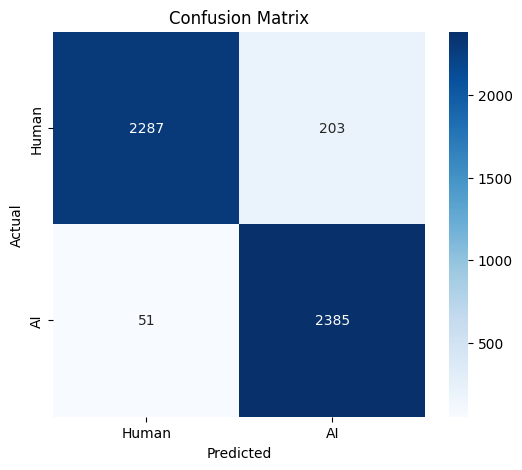

In [49]:
#===============================================
# Confusion Matrix
#===============================================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Human","AI"],
    yticklabels=["Human","AI"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [50]:
#======================================================
#Predictions On Custom Data
#======================================================
import torch
import torch.nn.functional as F

def predict_text(text):

    model.eval()

    encoding = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probs = F.softmax(
            outputs.logits,
            dim=1
        )

    human_prob = probs[0][0].item()
    ai_prob = probs[0][1].item()

    prediction = torch.argmax(
        probs,
        dim=1
    ).item()

    label = (
        "AI Generated"
        if prediction == 1
        else "Human Written"
    )

    confidence = max(
        human_prob,
        ai_prob
    ) * 100

    print("="*60)
    print("Prediction :", label)
    print(f"Confidence : {confidence:.2f}%")
    print(f"Human Prob : {human_prob:.4f}")
    print(f"AI Prob    : {ai_prob:.4f}")
    print("="*60)

    return {
        "prediction": label,
        "confidence": confidence,
        "human_prob": human_prob,
        "ai_prob": ai_prob
    }

In [51]:
human_text_1 = """
The Taj Mahal is an ivory-white marble mausoleum located in Agra, India.
It was commissioned in 1632 by the Mughal emperor Shah Jahan in memory
of his wife Mumtaz Mahal. The monument is widely regarded as one of the
finest examples of Mughal architecture and attracts millions of visitors
every year.
"""

predict_text(human_text_1)

Prediction : AI Generated
Confidence : 99.84%
Human Prob : 0.0016
AI Prob    : 0.9984


{'prediction': 'AI Generated',
 'confidence': 99.8376727104187,
 'human_prob': 0.0016232761554419994,
 'ai_prob': 0.998376727104187}

In [33]:
ai_text_1 = """
Artificial intelligence is revolutionizing industries across the globe
by enabling organizations to automate processes, improve efficiency,
and gain deeper insights from data. Businesses that adopt AI-driven
strategies are often better positioned to innovate and remain competitive
in rapidly changing markets.
"""

predict_text(ai_text_1)

Human Probability: 0.048247091472148895
AI Probability   : 0.9517529010772705
Prediction: AI


In [55]:
import pandas as pd

file_path = "/content/drive/MyDrive/Colab Notebooks/Evaluation_Samples/Test_Data.csv"

eval_df = pd.read_csv(file_path)

print("Shape:", eval_df.shape)

eval_df.head()

Shape: (20, 4)


,id,text,label,source
0,1,Modern humans arrived on the Indian subcontine...,0,wikipedia
1,2,The World Cup is globally regarded as the most...,0,wikipedia
2,3,They didn't announce any physical collector ed...,0,reddit
3,4,A candidate hoping to run for governor in the ...,0,bbc
4,5,"The Maurya Empire would collapse in 185 BCE, o...",0,wikipedia


In [56]:
print(eval_df.columns)

Index(['id', 'text', 'label', 'source'], dtype='object')


In [57]:
predictions = []
confidences = []

for text in eval_df["text"]:

    result = predict_text(text)

    pred = (
        1
        if result["prediction"] == "AI Generated"
        else 0
    )

    predictions.append(pred)
    confidences.append(result["confidence"])

eval_df["prediction"] = predictions
eval_df["confidence"] = confidences

Prediction : Human Written
Confidence : 99.84%
Human Prob : 0.9984
AI Prob    : 0.0016
Prediction : AI Generated
Confidence : 94.71%
Human Prob : 0.0529
AI Prob    : 0.9471
Prediction : Human Written
Confidence : 99.94%
Human Prob : 0.9994
AI Prob    : 0.0006
Prediction : AI Generated
Confidence : 64.08%
Human Prob : 0.3592
AI Prob    : 0.6408
Prediction : Human Written
Confidence : 76.97%
Human Prob : 0.7697
AI Prob    : 0.2303
Prediction : Human Written
Confidence : 99.83%
Human Prob : 0.9983
AI Prob    : 0.0017
Prediction : Human Written
Confidence : 99.96%
Human Prob : 0.9996
AI Prob    : 0.0004
Prediction : Human Written
Confidence : 99.97%
Human Prob : 0.9997
AI Prob    : 0.0003
Prediction : AI Generated
Confidence : 91.81%
Human Prob : 0.0819
AI Prob    : 0.9181
Prediction : Human Written
Confidence : 99.77%
Human Prob : 0.9977
AI Prob    : 0.0023
Prediction : Human Written
Confidence : 99.95%
Human Prob : 0.9995
AI Prob    : 0.0005
Prediction : AI Generated
Confidence : 99.87%


In [58]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    eval_df["label"],
    eval_df["prediction"]
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6000


In [59]:
wrong_preds = eval_df[
    eval_df["label"] != eval_df["prediction"]
]

print("Wrong Predictions:")
print(len(wrong_preds))

Wrong Predictions:
8


In [60]:
wrong_preds[
    ["text", "label", "prediction", "confidence"]
]

,text,label,prediction,confidence
1,The World Cup is globally regarded as the most...,0,1,94.712985
3,A candidate hoping to run for governor in the ...,0,1,64.080924
8,Sony began developing a sequel to Into the Spi...,0,1,91.812247
10,The rain had washed away the familiar scent of...,1,0,99.948078
14,Social and Democratic Fabric: Critics and inte...,1,0,97.542667
15,"One morning, Dave decided he was finally going...",1,0,99.992633
17,"In the United States, California’s primaries a...",1,0,64.673805
18,"As classical Greek civilization flourished, th...",1,0,94.666523


In [61]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    eval_df["label"],
    eval_df["prediction"]
)

print(cm)

[[7 3]
 [5 5]]


In [62]:
from sklearn.metrics import classification_report

print(
    classification_report(
        eval_df["label"],
        eval_df["prediction"],
        target_names=["Human", "AI"]
    )
)

              precision    recall  f1-score   support

       Human       0.58      0.70      0.64        10
          AI       0.62      0.50      0.56        10

    accuracy                           0.60        20
   macro avg       0.60      0.60      0.60        20
weighted avg       0.60      0.60      0.60        20

